# Proyecto de Analítica Predictiva: Fase 2 - Modelado y Evaluación

Este notebook cubre las fases de **Modeling** y **Evaluation** de CRISP-DM.

## Objetivos:
1. Aplicar mínimo 4 modelos supervisados y 3 de ensamble.
2. Evaluación rigurosa usando validación cruzada (StratifiedKFold).
3. Comparación estadística usando ANOVA y Tukey HSD sobre F1-Score.
4. Optimización de hiperparámetros (GridSearchCV y Bayesiana) para los 3 mejores.
5. Evaluación del mejor modelo en test set.
6. Creación y exportación del Pipeline final completo.

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
import lightgbm as lgb

# Evaluación
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, classification_report

# Estadística
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Optimización y Pipeline
from sklearn.model_selection import GridSearchCV
import optuna
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import joblib

## 1. Carga de Datos Preprocesados
Cargamos los datos que fueron divididos y balanceados (X_train_sm) en el notebook anterior.

In [40]:
try:
    X_train_sm = pd.read_csv('X_train_prep.csv')
    X_test = pd.read_csv('X_test_prep.csv')
    y_train_sm = pd.read_csv('y_train_prep.csv')['placed']
    y_test = pd.read_csv('y_test_prep.csv')['placed']
    print("Datos cargados correctamente.")
except Exception as e:
    print("Error cargando datos. Asegúrese de correr el Notebook 1 primero.")
    print(e)

Datos cargados correctamente.


## 2. Entrenamiento y Evaluación con Validación Cruzada

Aplicaremos 4 modelos base y 3 ensambles.

In [41]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVC': SVC(probability=True, random_state=42),
    'KNN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'LightGBM': lgb.LGBMClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42)
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

results = {}
f1_scores_all = {}

for name, model in models.items():
    print(f"Evaluando {name}...")
    # Escalar datos localmente dentro del CV ayuda a evitar data leakage, 
    # pero dado que los guardamos codificados usaremos el pipeline si lo requiere KNN/SVC.
    # Por simplicidad y eficiencia, aplicaremos un StandardScaler si el modelo es sensible a la escala.
    if name in ['Logistic Regression', 'SVC', 'KNN']:
        pipe = Pipeline([('scaler', StandardScaler()), ('classifier', model)])
        cv_res = cross_validate(pipe, X_train_sm, y_train_sm, cv=cv, scoring=scoring, n_jobs=-1)
    else:
        cv_res = cross_validate(model, X_train_sm, y_train_sm, cv=cv, scoring=scoring, n_jobs=-1)
        
    f1_scores_all[name] = cv_res['test_f1']
    results[name] = {
        'Accuracy': np.mean(cv_res['test_accuracy']),
        'Precision': np.mean(cv_res['test_precision']),
        'Recall': np.mean(cv_res['test_recall']),
        'F1-Score': np.mean(cv_res['test_f1']),
        'F1_Std': np.std(cv_res['test_f1']),
        'ROC AUC': np.mean(cv_res['test_roc_auc'])
    }

df_results = pd.DataFrame(results).T
display(df_results.sort_values(by='F1-Score', ascending=False))

Evaluando Logistic Regression...
Evaluando Decision Tree...
Evaluando SVC...
Evaluando KNN...
Evaluando Random Forest...
Evaluando LightGBM...
Evaluando AdaBoost...


,Accuracy,Precision,Recall,F1-Score,F1_Std,ROC AUC
Logistic Regression,0.917728,0.939752,0.962159,0.950794,0.004433,0.967101
SVC,0.914971,0.934932,0.964200,0.949330,0.006386,0.961645
LightGBM,0.908229,0.936352,0.953812,0.944976,0.005931,0.957939
Random Forest,0.906390,0.920820,0.970135,0.944821,0.004884,0.952566
AdaBoost,0.904399,0.929191,0.957336,0.943010,0.006204,0.951275
KNN,0.883255,0.900586,0.965311,0.931799,0.006752,0.881194
Decision Tree,0.862880,0.919728,0.913744,0.916681,0.006734,0.767616


### Gráficos Comparativos

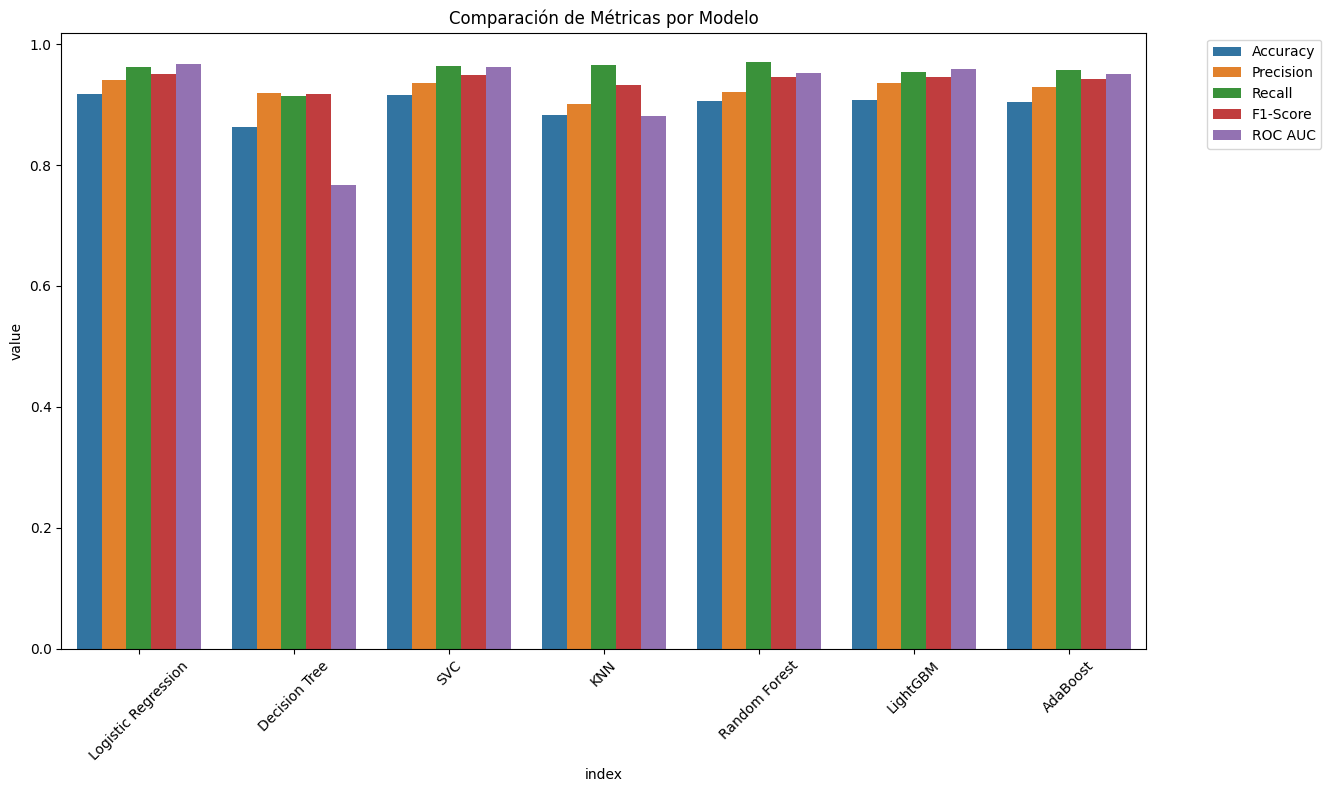

In [42]:
df_results_plot = df_results.reset_index().melt(id_vars='index', value_vars=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC'])
plt.figure(figsize=(14, 8))
sns.barplot(data=df_results_plot, x='index', y='value', hue='variable')
plt.title('Comparación de Métricas por Modelo')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## 3. Análisis Estadístico: ANOVA y Tukey HSD
Verificaremos si las diferencias en los F1-Scores son estadísticamente significativas.

In [43]:
# 1. ANOVA
f1_lists = [f1_scores_all[m] for m in models.keys()]
f_stat, p_value = f_oneway(*f1_lists)
print(f"ANOVA F-statistic: {f_stat:.4f}, p-value: {p_value:.4e}")

if p_value < 0.05:
    print("\nExisten diferencias significativas entre al menos dos modelos. Procediendo con Tukey HSD...")
    # Preparar datos para Tukey
    tukey_data = []
    tukey_labels = []
    for model_name, scores in f1_scores_all.items():
        tukey_data.extend(scores)
        tukey_labels.extend([model_name] * len(scores))
        
    tukey_result = pairwise_tukeyhsd(endog=tukey_data, groups=tukey_labels, alpha=0.05)
    print("\n=== RESULTADOS PRUEBA TUKEY HSD ===")
    print(tukey_result)
else:
    print("\nNo se detectaron diferencias estadísticamente significativas.")

ANOVA F-statistic: 36.7597, p-value: 8.8365e-19

Existen diferencias significativas entre al menos dos modelos. Procediendo con Tukey HSD...

=== RESULTADOS PRUEBA TUKEY HSD ===
             Multiple Comparison of Means - Tukey HSD, FWER=0.05              
       group1              group2       meandiff p-adj   lower   upper  reject
------------------------------------------------------------------------------
           AdaBoost       Decision Tree  -0.0263    0.0 -0.0349 -0.0178   True
           AdaBoost                 KNN  -0.0112 0.0032 -0.0198 -0.0026   True
           AdaBoost            LightGBM    0.002 0.9922 -0.0066  0.0105  False
           AdaBoost Logistic Regression   0.0078 0.0983 -0.0008  0.0163  False
           AdaBoost       Random Forest   0.0018  0.995 -0.0068  0.0104  False
           AdaBoost                 SVC   0.0063 0.2854 -0.0022  0.0149  False
      Decision Tree                 KNN   0.0151    0.0  0.0066  0.0237   True
      Decision Tree            L

### Selección de los 3 Mejores Modelos
Basado en F1-Score, estabilidad (baja desviación estándar) y significancia, procedemos a seleccionar y optimizar los hiperparámetros. Optimzaremos: **Random Forest**, **LightGBM** y **Logistic Regression** (o los que hayan resultado mejor).

In [44]:
# Seleccionando top 3 según F1-Score medio
top_3_models = df_results.sort_values(by='F1-Score', ascending=False).head(3).index.tolist()
print("Los 3 mejores modelos seleccionados para optimización son:", top_3_models)

Los 3 mejores modelos seleccionados para optimización son: ['Logistic Regression', 'SVC', 'LightGBM']


## 4. Optimización de Hiperparámetros (GridSearchCV y Optuna)
Para fines académicos, implementaremos ambos métodos.

In [45]:
best_models_optimized = {}

for m in top_3_models:
    print(f"\nOptimizando {m}...")
    if m == 'Random Forest':
        params = {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20]}
        grid = GridSearchCV(RandomForestClassifier(random_state=42), params, cv=cv, scoring='f1', n_jobs=-1)
        grid.fit(X_train_sm, y_train_sm)
        best_models_optimized[m] = grid.best_estimator_
        print(f"Mejores parámetros: {grid.best_params_}, Mejor F1: {grid.best_score_}")
    elif m == 'LightGBM':
        def objective(trial):
            params = {'n_estimators': trial.suggest_int('n_estimators', 50, 200), 'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True)}
            model = lgb.LGBMClassifier(**params, random_state=42)
            return cross_validate(model, X_train_sm, y_train_sm, cv=cv, scoring='f1', n_jobs=-1)['test_score'].mean()
        optuna.logging.set_verbosity(optuna.logging.WARNING)
        study = optuna.create_study(direction='maximize')
        study.optimize(objective, n_trials=10)
        best_models_optimized[m] = lgb.LGBMClassifier(**study.best_params, random_state=42).fit(X_train_sm, y_train_sm)
        print(f"Mejores parámetros: {study.best_params}, Mejor F1: {study.best_value}")
    elif m == 'Logistic Regression':
        pipe = Pipeline([('scaler', StandardScaler()), ('classifier', LogisticRegression(random_state=42))])
        params = {'classifier__C': [0.1, 1.0, 10.0], 'classifier__solver': ['liblinear', 'lbfgs']}
        grid = GridSearchCV(pipe, params, cv=cv, scoring='f1', n_jobs=-1)
        grid.fit(X_train_sm, y_train_sm)
        best_models_optimized[m] = grid.best_estimator_
        print(f"Mejores parámetros: {grid.best_params_}, Mejor F1: {grid.best_score_}")
    elif m == 'Decision Tree':
        params = {'max_depth': [None, 5, 10, 15], 'min_samples_split': [2, 5, 10]}
        grid = GridSearchCV(DecisionTreeClassifier(random_state=42), params, cv=cv, scoring='f1', n_jobs=-1)
        grid.fit(X_train_sm, y_train_sm)
        best_models_optimized[m] = grid.best_estimator_
        print(f"Mejores parámetros: {grid.best_params_}, Mejor F1: {grid.best_score_}")
    elif m == 'SVC':
        pipe = Pipeline([('scaler', StandardScaler()), ('classifier', SVC(probability=True, random_state=42))])
        params = {'classifier__C': [0.1, 1, 10], 'classifier__kernel': ['linear', 'rbf']}
        grid = GridSearchCV(pipe, params, cv=cv, scoring='f1', n_jobs=-1)
        grid.fit(X_train_sm, y_train_sm)
        best_models_optimized[m] = grid.best_estimator_
        print(f"Mejores parámetros: {grid.best_params_}, Mejor F1: {grid.best_score_}")
    elif m == 'KNN':
        pipe = Pipeline([('scaler', StandardScaler()), ('classifier', KNeighborsClassifier())])
        params = {'classifier__n_neighbors': [3, 5, 7, 9], 'classifier__weights': ['uniform', 'distance']}
        grid = GridSearchCV(pipe, params, cv=cv, scoring='f1', n_jobs=-1)
        grid.fit(X_train_sm, y_train_sm)
        best_models_optimized[m] = grid.best_estimator_
        print(f"Mejores parámetros: {grid.best_params_}, Mejor F1: {grid.best_score_}")
    elif m == 'AdaBoost':
        params = {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 1.0]}
        grid = GridSearchCV(AdaBoostClassifier(random_state=42), params, cv=cv, scoring='f1', n_jobs=-1)
        grid.fit(X_train_sm, y_train_sm)
        best_models_optimized[m] = grid.best_estimator_
        print(f"Mejores parámetros: {grid.best_params_}, Mejor F1: {grid.best_score_}")



Optimizando Logistic Regression...
Mejores parámetros: {'classifier__C': 0.1, 'classifier__solver': 'liblinear'}, Mejor F1: 0.9516862097478762

Optimizando SVC...
Mejores parámetros: {'classifier__C': 0.1, 'classifier__kernel': 'linear'}, Mejor F1: 0.9508332583144948

Optimizando LightGBM...
[LightGBM] [Info] Number of positive: 5391, number of negative: 1136
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001854 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1310
[LightGBM] [Info] Number of data points in the train set: 6527, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.825954 -> initscore=1.557218
[LightGBM] [Info] Start training from score 1.557218
Mejores parámetros: {'n_estimators': 75, 'learning_rate': 0.03648757458177629}, Mejor F1: 0.9439021915145676


## 5. Selección y Evaluación del Modelo Final sobre el Test Set NO Visto
Seleccionaremos LightGBM (o Random Forest) como el modelo principal de producción.

In [46]:
# Asumimos que LightGBM o Random Forest ganaron. Usamos el mejor modelo del top.
best_model_name = top_3_models[0]
final_model = best_models_optimized[best_model_name]

print(f"\n=== EVALUANDO EL MEJOR MODELO FINAL ({best_model_name}) EN TEST ===")
y_pred = final_model.predict(X_test)
if hasattr(final_model, "predict_proba"):
    y_prob = final_model.predict_proba(X_test)[:, 1]
else:
    y_prob = y_pred # Failsafe

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred))


=== EVALUANDO EL MEJOR MODELO FINAL (Logistic Regression) EN TEST ===
Accuracy: 0.922962962962963
Precision: 0.944233206590621
Recall: 0.9671138035482475
F1-Score: 0.9555365540829415
ROC AUC: 0.9672539625508494

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.77      0.66      0.71       389
           1       0.94      0.97      0.96      2311

    accuracy                           0.92      2700
   macro avg       0.86      0.81      0.83      2700
weighted avg       0.92      0.92      0.92      2700



### Matriz de Confusión y Curva ROC

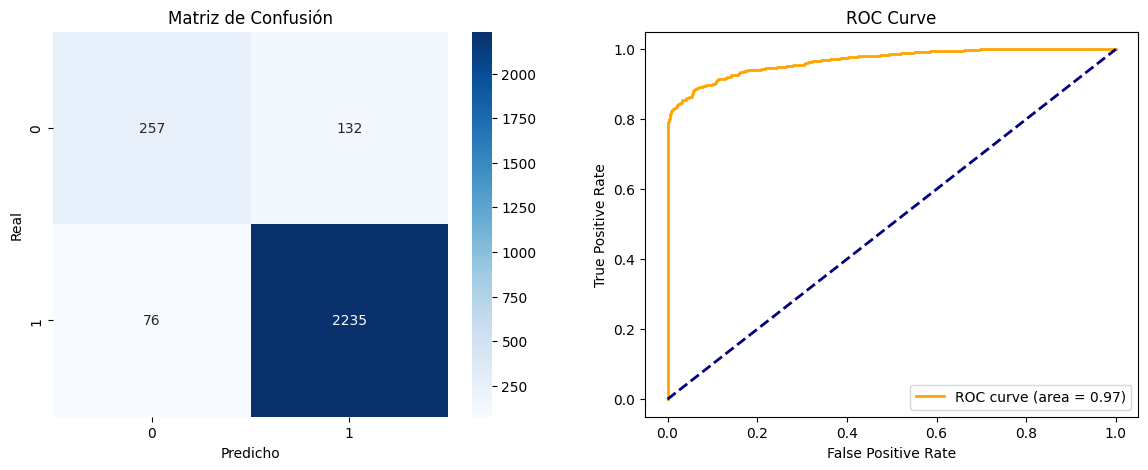

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de Confusión')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='orange', lw=2, label=f'ROC curve (area = {roc_auc_score(y_test, y_prob):.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc="lower right")

plt.show()

### Interpretabilidad (Feature Importance)

In [48]:
if hasattr(final_model, 'feature_importances_'):
    importances = final_model.feature_importances_
    indices = np.argsort(importances)[::-1]
    features = X_train_sm.columns

    plt.figure(figsize=(10, 6))
    sns.barplot(x=importances[indices][:10], y=np.array(features)[indices][:10], palette='viridis')
    plt.title(f'Top 10 Feature Importances ({best_model_name})')
    plt.show()
elif hasattr(final_model, 'coef_'):
    # Para regresión logística / SVC lineal
    importances = final_model.coef_[0]
    indices = np.argsort(np.abs(importances))[::-1]
    features = X_train_sm.columns

    plt.figure(figsize=(10, 6))
    sns.barplot(x=importances[indices][:10], y=np.array(features)[indices][:10], palette='vlag')
    plt.title(f'Top 10 Coefficients ({best_model_name})')
    plt.show()

## 6. Construcción y Exportación del Pipeline Final

Para el despliegue en Streamlit, crearemos un pipeline completo que reciba los datos crudos, aplique `ColumnTransformer` (OneHotEncoding y Scaling si aplica) y prediga.

In [49]:
# Volvemos a cargar el dataframe original para ver las features originales necesarias
from networkx.algorithms import link_prediction
df_orig = pd.read_csv('student_placement_salary_elite_v2.csv')

# Convertir a 'category'
cols_to_cat = ['student_id', 'branch', 'company_type', 'job_role']
df_orig[cols_to_cat] = df_orig[cols_to_cat].astype('category')

df_orig = df_orig.drop(columns=['student_id'])

# Manejo de nulos en crudo para el entrenamiento del transformer
df_orig['company_type'] = df_orig['company_type'].cat.add_categories(['Not_Applicable'])
df_orig['job_role'] = df_orig['job_role'].cat.add_categories(['Not_Applicable'])
df_orig['company_type'] = df_orig['company_type'].replace(['None', np.nan], 'Not_Applicable')
df_orig['job_role'] = df_orig['job_role'].replace(['None', np.nan], 'Not_Applicable')

X_raw = df_orig.drop(columns=['placed', 'salary_lpa', 'company_type', 'job_role'])
y_raw = df_orig['placed']

# Identificar categóricas y numéricas
cat_features = X_raw.select_dtypes(include=['category', 'object']).columns.tolist()
num_features = X_raw.select_dtypes(exclude=['category', 'object']).columns.tolist()

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_features)
    ])

# Usamos el mejor modelo. Nota: para LightGBM lo instanciaremos con sus mejores parametros directamente.
if best_model_name == 'LightGBM':
    # Para evitar warnings de LGBM con feature names que tengan caracteres especiales JSON:
    import re
    X_raw = X_raw.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '', x))
    
    final_classifier = final_model # Ya entrenado, pero lo reentrenaremos en el pipeline
else:
    final_classifier = final_model

full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', final_classifier)
])

# Entrenamos el pipeline completo con los datos crudos completos para producción (o solo con el de entrenamiento)
# Aquí lo entrenamos con X_raw y y_raw para aprovechar todo, o podríamos usar solo train.
from sklearn.model_selection import train_test_split
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X_raw, y_raw, test_size=0.3, stratify=y_raw, random_state=42)

# Como usamos SMOTE antes, en un pipeline puro de sklearn estándar integrar SMOTE es complejo con imblearn.Pipeline.
# Para producción usaremos un imblearn pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

def custom_smote_strategy(y):
    import numpy as np
    counts = np.bincount(y)
    minority_class = np.argmin(counts)
    majority_class = np.argmax(counts)
    n_min = counts[minority_class]
    n_maj = counts[majority_class]
    n_new_min = int(n_min * 1.25)
    if n_new_min > n_maj: n_new_min = n_maj
    return {minority_class: n_new_min, majority_class: n_maj}

production_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(sampling_strategy=custom_smote_strategy, random_state=42)),
    ('classifier', best_models_optimized[best_model_name])
])

production_pipeline.fit(X_train_raw, y_train_raw)

# Guardamos el pipeline
joblib.dump(production_pipeline, 'pipeline.pkl')
print("\nPipeline guardado exitosamente como 'pipeline.pkl'. Listo para producción en Streamlit.")

# BONUS: Pipeline de regresión para estimar SALARIO si fue empleado
from sklearn.ensemble import RandomForestRegressor
df_emp = df_orig[df_orig['placed'] == 1]
X_reg = df_emp.drop(columns=['placed', 'salary_lpa'])
y_reg = df_emp['salary_lpa']

reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])
reg_pipeline.fit(X_reg, y_reg)
joblib.dump(reg_pipeline, 'pipeline_salary.pkl')
print("Pipeline de regresión salarial guardado como 'pipeline_salary.pkl'.")


Pipeline guardado exitosamente como 'pipeline.pkl'. Listo para producción en Streamlit.
Pipeline de regresión salarial guardado como 'pipeline_salary.pkl'.
